# IPL Data Analytics Project

 


In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder


## Task 1: Load Dataset


In [ ]:
df = pd.read_csv("../dataset/matches.csv", encoding="latin1")

# Drop useless column because it is fully empty
if "umpire3" in df.columns:
    df = df.drop(columns=["umpire3"])

print("=== TASK 1: DATA UNDERSTANDING ===")
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Identify quantitative and qualitative columns
quantitative_cols = df.select_dtypes(include=np.number).columns
qualitative_cols = df.select_dtypes(exclude=np.number).columns

print("\nQuantitative Columns:")
print(list(quantitative_cols))

print("\nQualitative Columns:")
print(list(qualitative_cols))
 

=== TASK 1: DATA UNDERSTANDING ===

First 5 rows:
   id  season       city        date                        team1  \
0   1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1   2    2017       Pune  2017-04-06               Mumbai Indians   
2   3    2017     Rajkot  2017-04-07                Gujarat Lions   
3   4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4   5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  no

## Task 2: EDA



============ TASK 2: EDA ===============


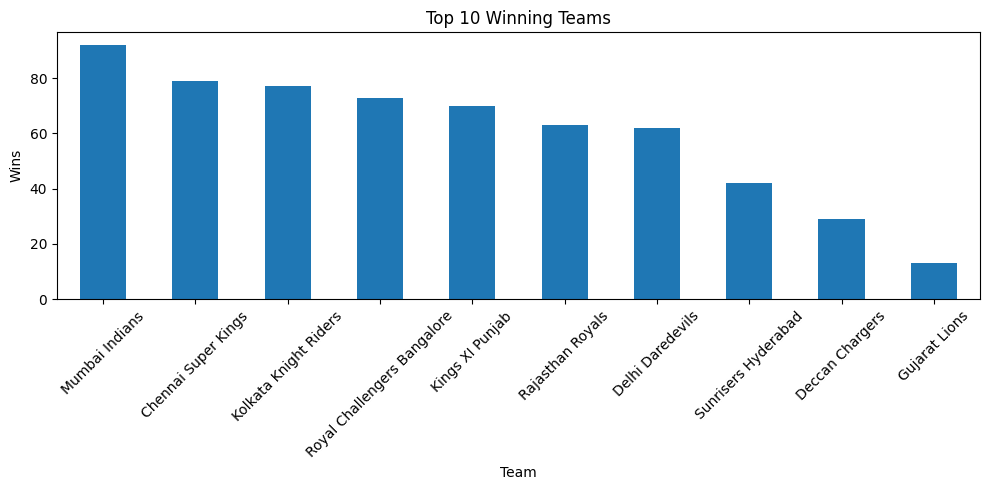

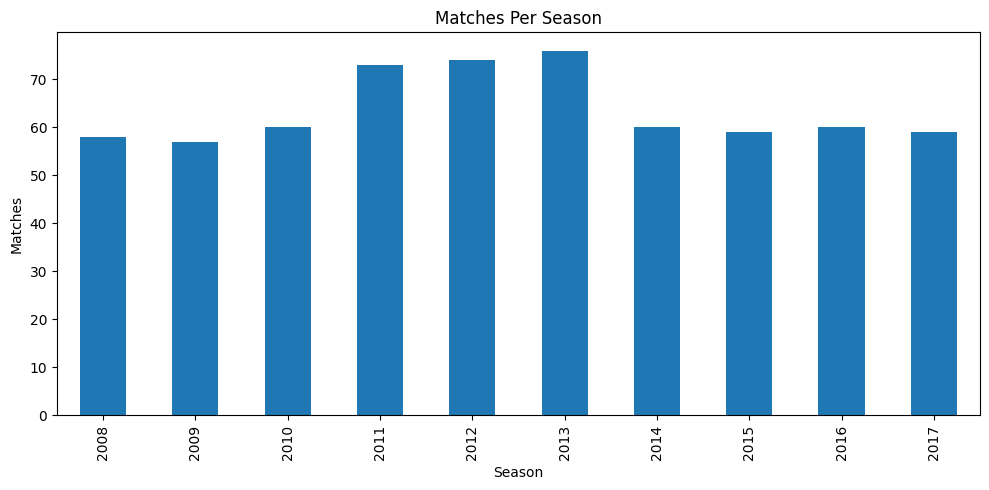

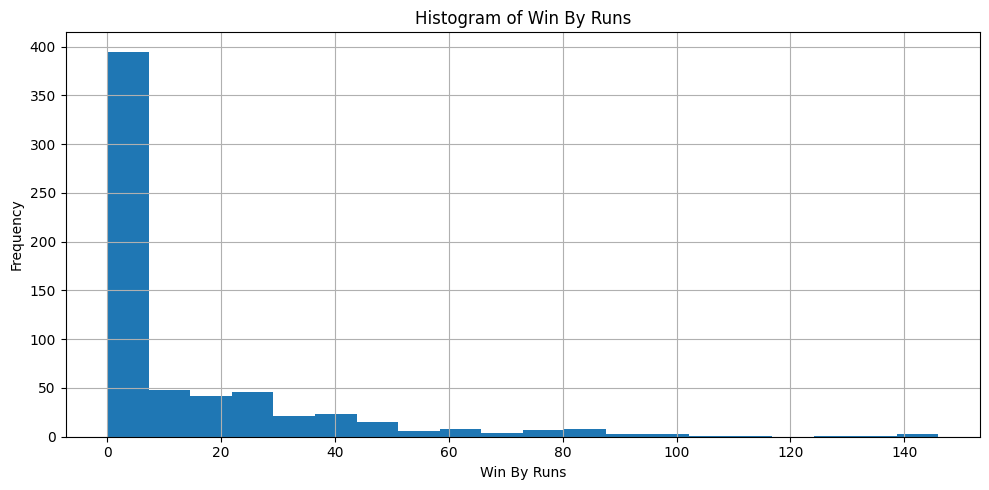

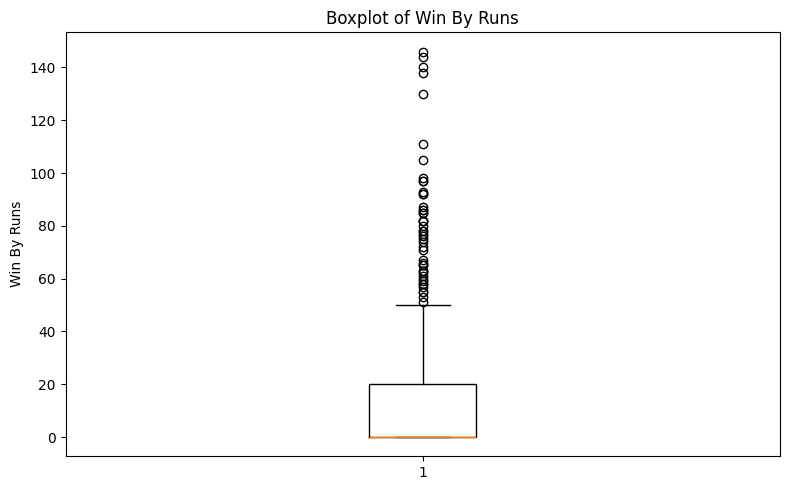

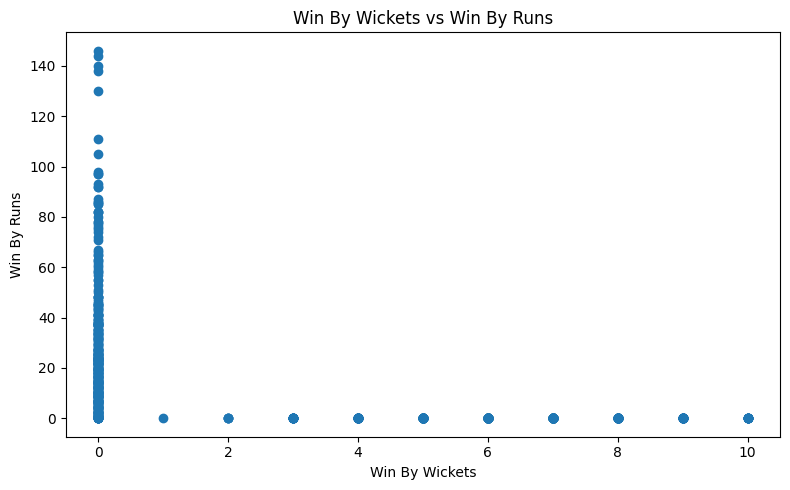


Correlation Matrix:
                      id    season  dl_applied  win_by_runs  win_by_wickets
id              1.000000  0.471087    0.024281    -0.010263       -0.015510
season          0.471087  1.000000    0.004170    -0.016815       -0.000708
dl_applied      0.024281  0.004170    1.000000    -0.010893       -0.011640
win_by_runs    -0.010263 -0.016815   -0.010893     1.000000       -0.565181
win_by_wickets -0.015510 -0.000708   -0.011640    -0.565181        1.000000


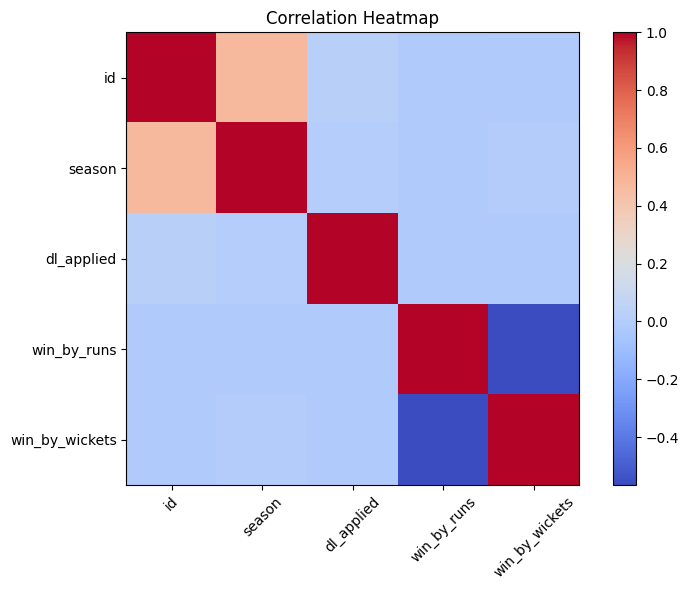

In [ ]:
print("\n============ TASK 2: EDA ===============")

# 1. Top winning teams
plt.figure(figsize=(10, 5))
winner_counts = df["winner"].fillna("No Result").value_counts()   
winner_counts.head(10).plot(kind="bar")
plt.title("Top 10 Winning Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Matches per season
plt.figure(figsize=(10, 5))
df["season"].value_counts().sort_index().plot(kind="bar")
plt.title("Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.tight_layout()
plt.show()

# 3. Histogram (Univariate) Distribution of wins by runs
plt.figure(figsize=(10, 5))
df["win_by_runs"].hist(bins=20)
plt.title("Histogram of Win By Runs")
plt.xlabel("Win By Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Boxplot (Univariate / Outlier check)
plt.figure(figsize=(8, 5))
plt.boxplot(df["win_by_runs"].dropna())
plt.title("Boxplot of Win By Runs")
plt.ylabel("Win By Runs")
plt.tight_layout()
plt.show()

# 5. Scatter Plot (Bivariate)
plt.figure(figsize=(8, 5))
plt.scatter(df["win_by_wickets"], df["win_by_runs"])
plt.title("Win By Wickets vs Win By Runs")
plt.xlabel("Win By Wickets")
plt.ylabel("Win By Runs")
plt.tight_layout()
plt.show()  

# 6. Correlation Matrix + Heatmap
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## Task 3: Missing Values and Outliers


In [ ]:
print("\n=============== TASK 3: MISSING VALUES HANDLING ===============")

df_clean = df.copy()

for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    else:
        if df_clean[col].mode().empty:
            df_clean[col] = df_clean[col].fillna("Unknown")
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())
    


=============== TASK 3: MISSING VALUES HANDLING ===============

Missing Values After Cleaning:
id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64


## Task 4: Spread of Data


In [12]:
print("\n=== TASK 4: SPREAD OF DATA ===")

for col in numeric_df.columns:
    print(f"\nColumn: {col}")
    print("Mean:", df_clean[col].mean())
    print("Median:", df_clean[col].median())
    print("Standard Deviation:", df_clean[col].std())
    print("Skewness:", df_clean[col].skew())
    print("Kurtosis:", df_clean[col].kurt())



=== TASK 4: SPREAD OF DATA ===

Column: id
Mean: 318.5
Median: 318.5
Standard Deviation: 183.74166647769363
Skewness: 0.0
Kurtosis: -1.2

Column: season
Mean: 2012.4905660377358
Median: 2012.0
Standard Deviation: 2.7730262601942015
Skewness: 0.022129067423926355
Kurtosis: -1.108749817374726

Column: dl_applied
Mean: 0.025157232704402517
Median: 0.0
Standard Deviation: 0.1567257712213548
Skewness: 6.0786517787625325
Kurtosis: 35.06025044887934

Column: win_by_runs
Mean: 13.682389937106919
Median: 0.0
Standard Deviation: 23.908876971926833
Skewness: 2.5220633095183893
Kurtosis: 7.458171119563962

Column: win_by_wickets
Mean: 3.3726415094339623
Median: 4.0
Standard Deviation: 3.4203384191046635
Skewness: 0.26765600245962706
Kurtosis: -1.5317292793264188


## Task 5: Automating EDA


In [13]:
print("\n=============== TASK 5: AUTOMATING EDA ===============")

def basic_eda(dataframe):
    print("\nDescribe:")
    print(dataframe.describe())

    print("\nInfo:")
    print(dataframe.info())

    print("\nNull Values:")
    print(dataframe.isnull().sum())

    print("\nCorrelation:")
    print(dataframe.select_dtypes(include=np.number).corr())

basic_eda(df_clean)



=============== TASK 5: AUTOMATING EDA ===============

Describe:
               id       season  dl_applied  win_by_runs  win_by_wickets
count  636.000000   636.000000  636.000000   636.000000      636.000000
mean   318.500000  2012.490566    0.025157    13.682390        3.372642
std    183.741666     2.773026    0.156726    23.908877        3.420338
min      1.000000  2008.000000    0.000000     0.000000        0.000000
25%    159.750000  2010.000000    0.000000     0.000000        0.000000
50%    318.500000  2012.000000    0.000000     0.000000        4.000000
75%    477.250000  2015.000000    0.000000    20.000000        7.000000
max    636.000000  2017.000000    1.000000   146.000000       10.000000

Info:
<class 'pandas.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               636 non-null    int64
 1   season           636 non-null    int64
 2   cit

## Task 6: Simple Linear Regression


In [14]:
print("\n=============== TASK 6: SIMPLE LINEAR REGRESSION ===============")

simple_df = df_clean[["win_by_wickets", "win_by_runs"]]

X_simple = simple_df[["win_by_wickets"]]
y_simple = simple_df["win_by_runs"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

pred_simple = simple_model.predict(X_test_s)

print("Coefficient:", simple_model.coef_)
print("Intercept:", simple_model.intercept_)



=============== TASK 6: SIMPLE LINEAR REGRESSION ===============
Coefficient: [-3.91395908]
Intercept: 26.772583308671507


## Task 7: Multiple Linear Regression


In [15]:
print("\n=== TASK 7: MULTIPLE LINEAR REGRESSION ===")

multi_df = df_clean[["win_by_wickets", "dl_applied", "win_by_runs"]]

X_multi = multi_df[["win_by_wickets", "dl_applied"]]
y_multi = multi_df["win_by_runs"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

pred_multi = multi_model.predict(X_test_m)

print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)



=== TASK 7: MULTIPLE LINEAR REGRESSION ===
Coefficients: [-3.91687289 -1.45737958]
Intercept: 26.813908885809106


## Task 8 / 9: Overfitting and Underfitting


In [16]:
print("\n=== TASK 8 / 9: OVERFITTING AND UNDERFITTING ===")
print("Overfitting means model performs well on training data but poorly on testing data.")
print("Underfitting means model is too simple and performs poorly on both training and testing data.")

simple_train_score = simple_model.score(X_train_s, y_train_s)
simple_test_score = simple_model.score(X_test_s, y_test_s)

multi_train_score = multi_model.score(X_train_m, y_train_m)
multi_test_score = multi_model.score(X_test_m, y_test_m)

print("\nSimple Regression Train Score:", simple_train_score)
print("Simple Regression Test Score:", simple_test_score)

print("\nMultiple Regression Train Score:", multi_train_score)
print("Multiple Regression Test Score:", multi_test_score)



=== TASK 8 / 9: OVERFITTING AND UNDERFITTING ===
Overfitting means model performs well on training data but poorly on testing data.
Underfitting means model is too simple and performs poorly on both training and testing data.

Simple Regression Train Score: 0.3055471951302733
Simple Regression Test Score: 0.38256005316942265

Multiple Regression Train Score: 0.3056237787837558
Multiple Regression Test Score: 0.3835670463090637


## Task 10: Classification


In [17]:
print("\n=== TASK 10: CLASSIFICATION ===")

class_df = df_clean[["team1", "team2", "winner"]].copy()

le_team1 = LabelEncoder()
le_team2 = LabelEncoder()
le_winner = LabelEncoder()

class_df["team1"] = le_team1.fit_transform(class_df["team1"])
class_df["team2"] = le_team2.fit_transform(class_df["team2"])
class_df["winner"] = le_winner.fit_transform(class_df["winner"])

X_class = class_df[["team1", "team2"]]
y_class = class_df["winner"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

class_model = LogisticRegression(max_iter=5000)
class_model.fit(X_train_c, y_train_c)

pred_class = class_model.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, pred_class))



=== TASK 10: CLASSIFICATION ===
Accuracy: 0.234375
Confusion Matrix:
 [[18  0  1  0  0  0  3  0  0  0  0  0]
 [ 3  0  0  0  0  0  1  0  0  0  0  0]
 [ 8  0  0  0  1  0  0  0  0  0  0  0]
 [ 1  0  0  0  1  0  3  0  0  0  0  0]
 [ 8  0  0  0  0  0  4  0  0  0  1  0]
 [ 7  0  0  0  1  0  4  0  0  0  5  0]
 [ 2  0  6  0  0  0  5  0  0  0  2  1]
 [ 0  0  1  0  0  0  1  0  0  0  0  0]
 [ 0  0  1  0  0  0  9  0  0  0  1  2]
 [ 0  0  0  0  0  0  1  0  0  0  1  1]
 [ 0  0  0  0  0  0  6  0  0  0  7  4]
 [ 0  0  0  0  0  0  4  0  0  0  3  0]]


## Task 10: Logistic Regression Classification


In [18]:
print("\n=== TASK 10: LOGISTIC REGRESSION CLASSIFICATION ===")

class_df = df_clean[["team1", "team2", "toss_winner", "toss_decision", "winner"]].copy()

# missing rows remove
class_df = class_df.dropna()

# label encoding
encoders = {}
for col in class_df.columns:
    le = LabelEncoder()
    class_df[col] = le.fit_transform(class_df[col].astype(str))
    encoders[col] = le

X_class = class_df[["team1", "team2", "toss_winner", "toss_decision"]]
y_class = class_df["winner"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_c, y_train_c)

pred_class = log_model.predict(X_test_c)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test_c, pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, pred_class))



=== TASK 10: LOGISTIC REGRESSION CLASSIFICATION ===

Logistic Regression Results:
Accuracy: 0.2578125
Confusion Matrix:
 [[18  0  1  0  1  1  1  0  0  0  0  0]
 [ 3  0  0  0  0  0  1  0  0  0  0  0]
 [ 7  0  1  0  0  0  1  0  0  0  0  0]
 [ 0  0  1  0  1  0  3  0  0  0  0  0]
 [ 3  0  5  0  2  0  2  0  0  0  1  0]
 [ 4  0  1  0  5  0  1  0  0  0  6  0]
 [ 1  0  6  0  1  0  4  0  0  0  3  1]
 [ 1  0  0  0  0  0  1  0  0  0  0  0]
 [ 2  0  0  0  0  1  8  0  0  0  0  2]
 [ 0  0  0  0  0  0  0  0  0  0  2  1]
 [ 0  0  1  0  0  0  4  0  0  0  8  4]
 [ 0  0  0  0  0  1  3  0  0  0  3  0]]


## Task 11: Model Evaluation


In [19]:
print("\n=============== TASK 11: MODEL EVALUATION ===============")

simple_mse = mean_squared_error(y_test_s, pred_simple)
simple_mae = mean_absolute_error(y_test_s, pred_simple)
simple_r2 = r2_score(y_test_s, pred_simple)

print("\nSimple Linear Regression:")
print("MSE:", simple_mse)
print("MAE:", simple_mae)
print("R2 Score:", simple_r2)

multi_mse = mean_squared_error(y_test_m, pred_multi)
multi_mae = mean_absolute_error(y_test_m, pred_multi)
multi_r2 = r2_score(y_test_m, pred_multi)

print("\nMultiple Linear Regression:")
print("MSE:", multi_mse)
print("MAE:", multi_mae)
print("R2 Score:", multi_r2)



=============== TASK 11: MODEL EVALUATION ===============

Simple Linear Regression:
MSE: 314.4029157091183
MAE: 11.884882048734827
R2 Score: 0.38256005316942265

Multiple Linear Regression:
MSE: 313.89015073362975
MAE: 11.878173419997477
R2 Score: 0.3835670463090637


## Task 12: Final Model Performance


In [20]:
print("\n=== TASK 12: FINAL PERFORMANCE INTERPRETATION ===")
print("Simple Regression R2:", simple_r2)
print("Multiple Regression R2:", multi_r2)
print("Classification Accuracy:", accuracy_score(y_test_c, pred_class))



=== TASK 12: FINAL PERFORMANCE INTERPRETATION ===
Simple Regression R2: 0.38256005316942265
Multiple Regression R2: 0.3835670463090637
Classification Accuracy: 0.2578125


## Task 13: Final Visualization



=============== TASK 13: FINAL VISUALIZATION ===============


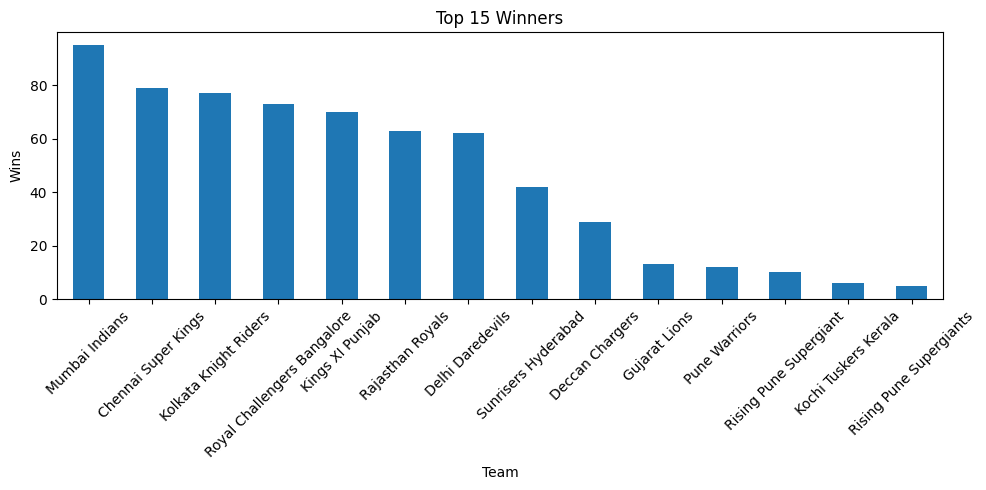


===================================== PROJECT COMPLETE =====================================


In [21]:
print("\n=============== TASK 13: FINAL VISUALIZATION ===============")

plt.figure(figsize=(10, 5))
df_clean["winner"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Winners")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n===================================== PROJECT COMPLETE =====================================")
